### Data Generation for frustrated lattices (Heisenberg J1-J2 models)
This notebook provides examples and tests for modules `spin_lattices` and `heisenberg_hamiltonians`.

In [2]:
# import black
# import jupyter_black

# jupyter_black.load(
#     lab=False,
#     line_length=79,
#     target_version=black.TargetVersion.PY39,
# )

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import yaml
from heisenberg_hamiltonians import (
    make_unpacked_configurations,
    HeisenbergJ1J2,
    SpinSystem,
)

from spin_lattices import (
    SpinLattice,
    ChainLattice,
    SquareLattice,
    KagomeLattice,
    TriangularLattice,
    SquareLattice1Diag,
    SquareLatticeNoDiag,
    scatter_plot
)

from matplotlib import colormaps
from pathlib import Path
import json
from sympy.combinatorics import Permutation, PermutationGroup
import numpy.typing as npt
from typing import Any

## Lattices

2024-01-23 22:08:36.402 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=16
2024-01-23 22:08:36.404 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-23 22:08:36.405 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-23 22:08:36.406 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-23 22:08:36.419 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 12870
2024-01-23 22:08:36.431 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLatticeNoDiag4x4-1.0-1.0-False-None-1.pickle
2024-01-23 22:08:36.434 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -44.9139328337


<Axes: xlabel='emb_x', ylabel='emb_y'>

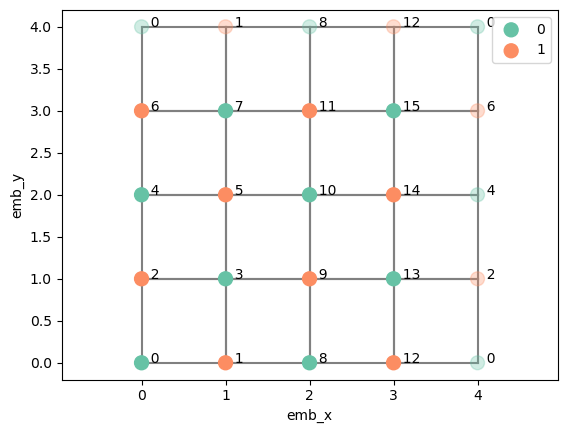

In [39]:
lattice = SquareLatticeNoDiag(4, 4)
system = HeisenbergJ1J2(
    lattice,
    use_symmetries=False,
    spin_inversion=None,
)
system.get_eigenstates(1)
spin = system.get_df_ground_state().sort_values('amplitude', ascending=False).index[0]
lattice.plot(spins=spin)

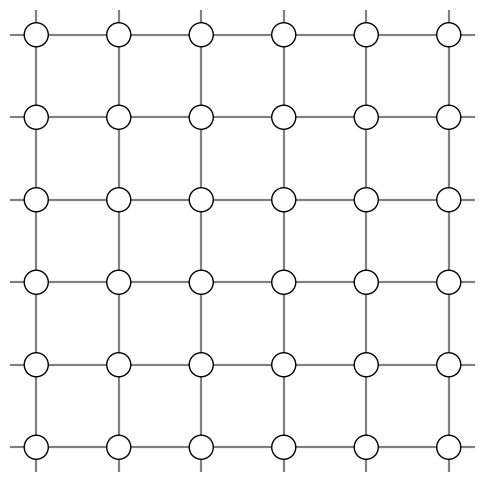

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))

SquareLatticeNoDiag(8, 8).plot(
    show_boundary_conditions=False,
    color_map={0: "white", 1: "lightgreen"},
    scatter_kws=dict(s=300, edgecolors="black", legend=False),
    show_numbers=False,
    ax=ax
)
ax.axis("off")
ax.margins(-0.1)
fig.savefig("fig/square-lattice-no-diag.png", dpi=300)

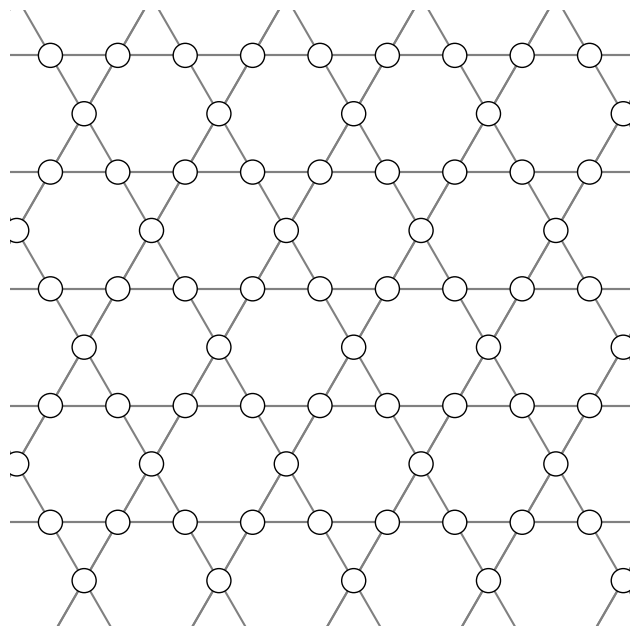

In [41]:
fig, ax = plt.subplots(figsize=(8, 8))

KagomeLattice(16, 16, isotropic=True).plot(
    show_boundary_conditions=False,
    color_map={0: "white", 1: "lightgreen"},
    scatter_kws=dict(s=300, edgecolors="black", legend=False),
    show_numbers=False,
    ax=ax
)
ax.axis("off")
ax.margins(-0.4)
fig.savefig("fig/kagome-lattice-isotropic.png", dpi=300)

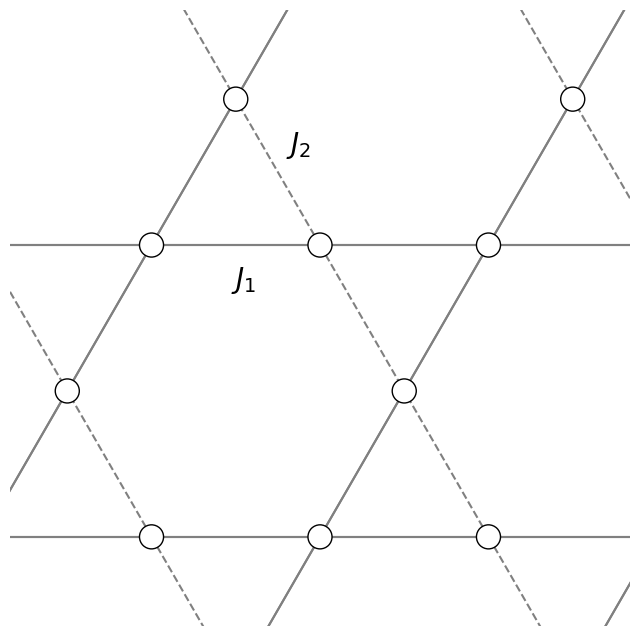

In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

KagomeLattice(16, 16, isotropic=False).plot(
    show_boundary_conditions=False,
    color_map={0: "white", 1: "lightgreen"},
    scatter_kws=dict(s=300, edgecolors="black", legend=False),
    show_numbers=False,
    ax=ax
)
ax.axis("off")
ax.text(22.8, 14.4, "$J_2$", fontsize=20)
ax.text(22.47, 13.6, "$J_1$", fontsize=20)
ax.margins(-0.46)
fig.savefig("fig/kagome-lattice-non-isotropic.png", dpi=300)

In [43]:
def plot_spin_arrows(
    lattice,
    spin,
    ax,
    quiver_kwargs: dict[str, Any] | None = None,
    scatter_kws=None,
    margin=0.05,
):
    if quiver_kwargs is None:
        quiver_kwargs = {}
    if scatter_kws is None:
        scatter_kws = {}
    lattice.plot(
        show_numbers=False,
        ax=ax,
        scatter_kws=dict(
            edgecolors="black", color="white", marker="o", s=300, linewidths=0.3
        )
        | scatter_kws,
        show_boundary_conditions=False,
    )
    ax.axis("off")
    ax.margins(margin)
    # turn off legend
    ax.get_legend().remove()
    spins = make_unpacked_configurations(spin, lattice.number_spins)
    sites_df = lattice.sites_df.query("is_canonical")
    assert np.allclose(sites_df["num"], np.arange(lattice.number_spins))
    colormap = colormaps.get_cmap("tab10")

    ax.quiver(
        sites_df["emb_x"],
        sites_df["emb_y"],
        [0] * lattice.number_spins,
        1 - 2 * spins.astype(np.float64),
        color=colormap(spins),
        **(
            dict(
                scale=15,
                pivot="mid",
                headwidth=3,
                headlength=3,
                headaxislength=2.5,
                width=0.015,
                zorder=30,
            )
            | quiver_kwargs
        ),
    )
    return ax


def plot_spins_arrows(
    lattice: SpinLattice,
    spins: npt.NDArray[np.uint64],
    titles: list[str],
    legend=True,
    size_scale: float | None = 3,
    size_scale_x: float | None = None,
    size_scale_y: float | None = None,
    col_wrap: int = 10,
    margin=0.05,
    quiver_kwargs: dict[str, Any] | None = None,
    scatter_kws=None,
    title_fontsize=None,
):
    if quiver_kwargs is None:
        quiver_kwargs = {}

    if size_scale is not None and (
        size_scale_x is not None or size_scale_y is not None
    ):
        raise ValueError(
            "size_scale cannot be used together with size_scale_x or size_scale_y"
        )
    if size_scale_x is None:
        size_scale_x = size_scale
    if size_scale_y is None:
        size_scale_y = size_scale
    # Calculate the number of rows and columns
    n_subsets = len(spins)
    n_cols = min(n_subsets, col_wrap)
    n_rows = (n_subsets + col_wrap - 1) // col_wrap

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * size_scale_x, n_rows * size_scale_y),
        squeeze=False,
    )

    # Flatten the axes array for easy iteration
    axes_flat = axes.flat

    # Iterate and plot
    for ax, spin, title in zip(axes_flat, spins, titles):
        plot_spin_arrows(
            lattice,
            spin=spin,
            ax=ax,
            margin=margin,
            quiver_kwargs=quiver_kwargs,
            scatter_kws=scatter_kws,
        )
        ax.axis("off")
        ax.set_title(title, fontsize=title_fontsize)
        # Correctly handle the legend
        if not legend and ax.get_legend():
            ax.get_legend().remove()

    # Hide any unused axes
    for ax in axes_flat[n_subsets:]:
        ax.set_visible(False)

    # fig.tight_layout()
    return fig


n_images = 5


# fig.savefig("fig/square-lattice-no-diag-marshall.png",  dpi=300)

In [44]:
def plot_ground_state(
    system: SpinSystem,
    n_images=5,
    start_basis_element=0,
    spins_arrows_kws: dict[str, Any] | None=None,
    quiver_kwargs: dict[str, Any] | None=None,
    scatter_kws: dict[str, Any]| None=None,
):
    if quiver_kwargs is None:
        quiver_kwargs = dict(scale=10)
    if scatter_kws is None:
        scatter_kws = {}
    if spins_arrows_kws is None:
        spins_arrows_kws = dict(margin=0.05, scale_size=2)
    lattice = system.lattice
    system.get_eigenstates(1)
    fig = plot_spins_arrows(
        lattice,
        system.get_df_ground_state()
        .sort_values("amplitude", ascending=False)
        .index[start_basis_element : start_basis_element + n_images],
        titles=[
            f"${coeff:0.4f}$"
            for coeff in system.get_df_ground_state()
            .sort_values("amplitude", ascending=False)["eigenstate_coeff"]
            .values[start_basis_element : start_basis_element + n_images]
        ],
        quiver_kwargs=quiver_kwargs,
        scatter_kws=scatter_kws,
        **spins_arrows_kws,
    )
    fig.tight_layout()
    return fig

2024-01-23 22:08:49.446 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=16
2024-01-23 22:08:49.447 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-23 22:08:49.449 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-23 22:08:49.450 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-23 22:08:49.461 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 12870
2024-01-23 22:08:49.472 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLatticeNoDiag4x4-1.0-1.0-False-None-1.pickle
2024-01-23 22:08:49.473 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -44.9139328337


2024-01-23 22:08:49.894 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=16
2024-01-23 22:08:49.896 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-23 22:08:49.898 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-23 22:08:49.899 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-23 22:08:49.910 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 12870
2024-01-23 22:08:49.919 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLatticeNoDiag4x4-1.0-1.0-False-None-1.pickle
2024-01-23 22:08:49.920 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -44.9139328337


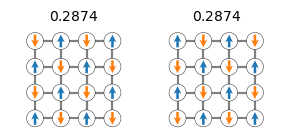

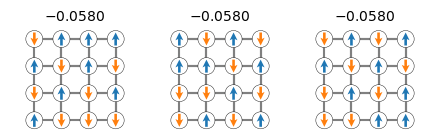

In [45]:
kwargs = dict(
    quiver_kwargs=dict(
        scale=10, headwidth=3, headlength=3, headaxislength=2.5, width=0.02
    ),
    scatter_kws=dict(s=150, linewidths=0.3),
    spins_arrows_kws=dict(margin=0.4,size_scale=1.5, 
        title_fontsize=20,),
)
fig = plot_ground_state(
    HeisenbergJ1J2(
        SquareLatticeNoDiag(4, 4), use_symmetries=False, spin_inversion=None
    ),
    n_images=2,
    start_basis_element=0,
    **kwargs,
)

fig.savefig("fig/square-ground-state-0-1.png", dpi=300)

fig = plot_ground_state(
    HeisenbergJ1J2(
        SquareLatticeNoDiag(4, 4), use_symmetries=False, spin_inversion=None
    ),
    n_images=3,
    start_basis_element=2,
    **kwargs,
)
fig.savefig("fig/square-ground-state-2-5.png", dpi=300)


2024-01-23 22:08:50.827 | DEBUG    | heisenberg_hamiltonians:__init__:511 - use_symmetries is None and lattice is not in symmetries whitelist, setting use_symmetries=False
2024-01-23 22:08:50.828 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-23 22:08:50.829 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-23 22:08:50.831 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-23 22:08:50.832 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-23 22:08:50.907 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-23 22:08:50.923 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2_isotropic-1.0-1.0-False-None-1.pickle


2024-01-23 22:08:50.951 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923
2024-01-23 22:08:52.950 | DEBUG    | heisenberg_hamiltonians:__init__:511 - use_symmetries is None and lattice is not in symmetries whitelist, setting use_symmetries=False
2024-01-23 22:08:52.953 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-01-23 22:08:52.954 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-23 22:08:52.955 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-23 22:08:52.956 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-23 22:08:53.030 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-01-23 22:08:53.044 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice4x2_i

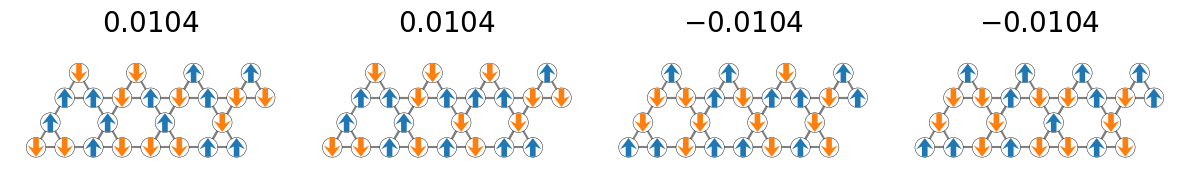

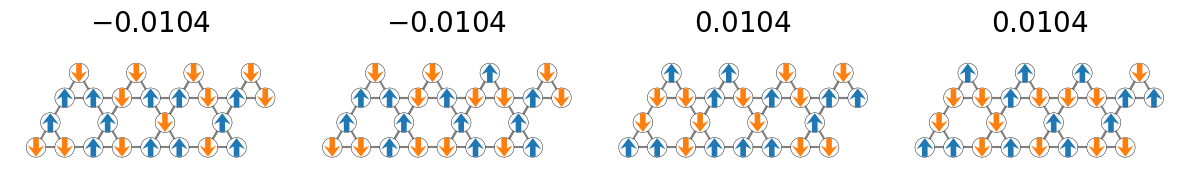

In [46]:
kwargs = dict(
    spins_arrows_kws=dict(
        size_scale=None,
        size_scale_x=3,
        size_scale_y=2,
        margin=-0.1,
        title_fontsize=20,
    ),
    quiver_kwargs=dict(
        scale=15, headwidth=3, headlength=2, headaxislength=1.5, width=0.02
    ),
    scatter_kws=dict(s=200, linewidths=0.3),
)
fig = plot_ground_state(
    HeisenbergJ1J2(
        KagomeLattice(4, 2, isotropic=True),
    ),
    n_images=4,
    start_basis_element=0,
    **kwargs
)
fig.savefig("fig/kagome-ground-state-0-4.png", dpi=300)

fig = plot_ground_state(
    HeisenbergJ1J2(
        KagomeLattice(4, 2, isotropic=True),
    ),
    n_images=4,
    start_basis_element=4,
    **kwargs
)
fig.savefig("fig/kagome-ground-state-4-8.png", dpi=300)

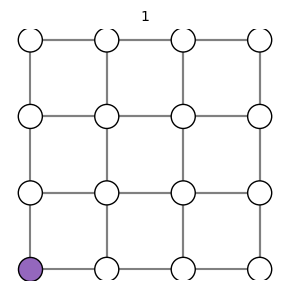

In [47]:
# lattice.plot(
#     show_boundary_conditions=False,
#     show_numbers=False,
#     spins=12,
#     color_map={0: "white", 1: "C4"},
#     scatter_kws=dict(s=300, edgecolors="black"),
# )

fig = lattice.plot_subsets(
    subsets=[1],
    titles=['1'],
    show_boundary_conditions=False,
    show_numbers=False,
    color_map={0: "white", 1: "C4"},
    scatter_kws=dict(s=300, edgecolors="black"),
    legend=False,
)
fig.axes[0].margins(0.05)
fig.tight_layout()


In [43]:
system.get_df_ground_state().sort_values("amplitude", ascending=False)

,eigenstate_coeff,amplitude
23142,0.287392,0.287392
42393,0.287392,0.287392
21350,-0.057990,0.057990
42381,-0.057990,0.057990
19047,-0.057990,0.057990
...,...,...
47875,0.000528,0.000528
40834,0.000528,0.000528
8767,0.000528,0.000528
17660,0.000528,0.000528


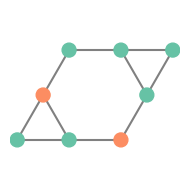

In [15]:
fig, ax = plt.subplots(figsize=(2, 2))
KagomeLattice(1, 1, boundary_conditions="open", isotropic=True).plot(show_numbers=False, ax=ax, spins=12)
ax.axis("off")
# turn off legend
ax.get_legend().remove()
fig.tight_layout()
fig.savefig("fig/kagome-lattice-isotropic-small.png", density=True)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

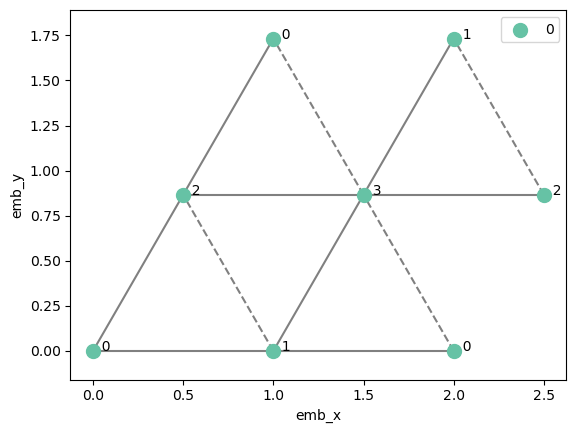

In [ ]:
lat = TriangleLattice(width=2, height=2)
lat.plot()

#### Chain Lattice (1dim)

number_spins=12
Symmetry group contains 0 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 924


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -21.5495636698


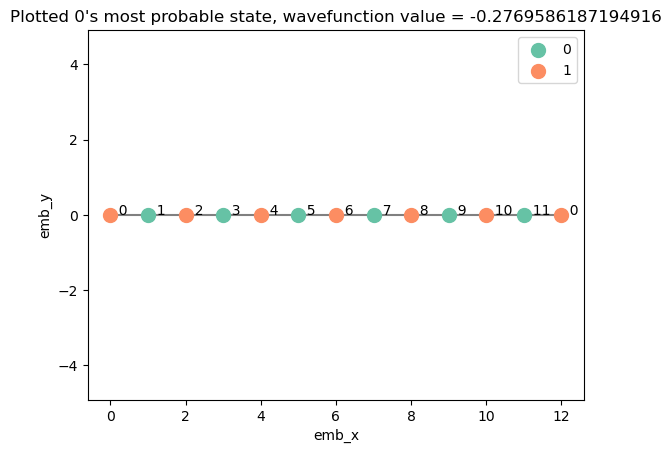

In [ ]:
system_nosym = HeisenbergJ1J2(
    ChainLattice(width=12),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
energy, state = system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

Antiferromagnetic, as expected

number_spins=12
Symmetry group contains 24 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 35
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -21.5495636698


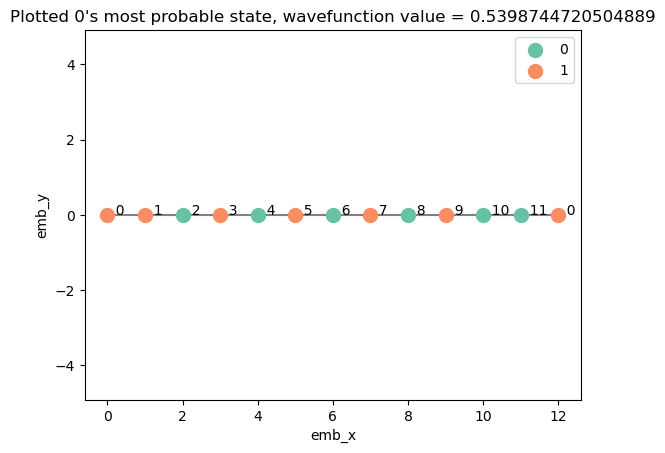

In [ ]:
system_sym = HeisenbergJ1J2(ChainLattice(width=12), J1=1, J2=0, use_symmetries=True)
energy, state = system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0, canonical_basis=False)

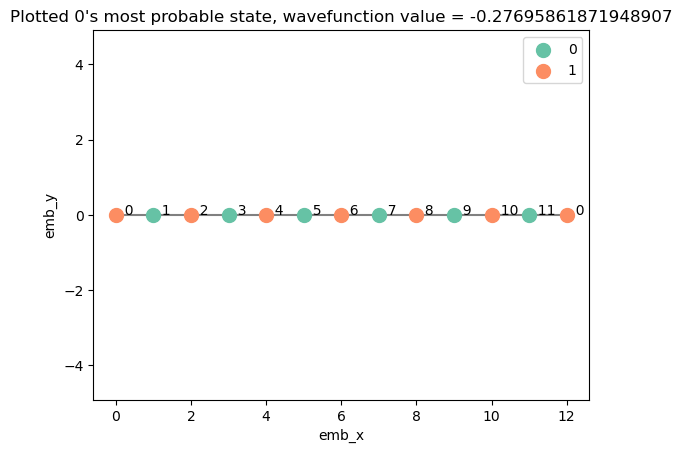

In [ ]:
system_sym.visualize_probable_configurations(m=0, canonical_basis=True)

### Checks

#### 4×4 SquareLattice, J2=0

In [ ]:
json_basis = json.loads(Path("basis_0_1_8.json").read_text())

In [ ]:
permutations = [sym['permutation'] for sym in json_basis['symmetries']]

In [ ]:
len(set(map(tuple, permutations))) == len(permutations)

True

In [ ]:
lat = SquareLattice(4, 4, enumerate_along='x')
set(map(tuple, permutations)).issubset(set(map(tuple, lat.get_automorphisms())))

True

In [ ]:
my_translations = [
    tuple(x.array_form)
    for x in PermutationGroup(
        Permutation(lat.get_translation("x")), Permutation(lat.get_translation("y"))
    ).elements
]

In [ ]:
set(my_translations) == set(map(tuple, permutations))

True

2024-01-19 17:02:50.617 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=16
2024-01-19 17:02:50.619 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-01-19 17:02:50.621 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-01-19 17:02:50.622 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-01-19 17:02:50.644 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 12870
2024-01-19 17:02:50.680 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-False-None-1.pickle
2024-01-19 17:02:50.684 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -44.9139328337


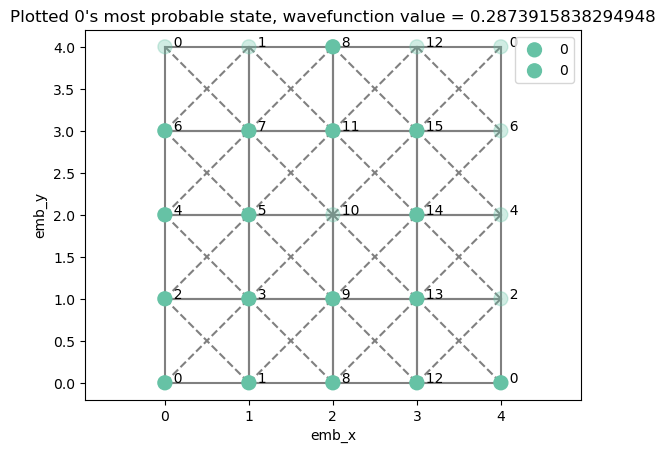

In [33]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

<Axes: xlabel='emb_x', ylabel='emb_y'>

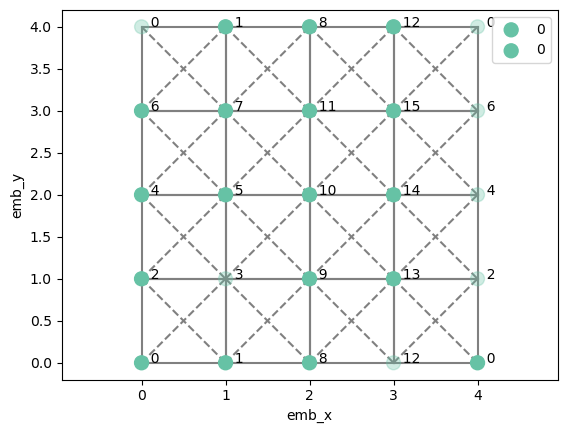

In [38]:
SquareLattice(width=4, height=4).plot(spins=7051)

In [36]:
system_nosym.get_df_ground_state().sort_values("amplitude")

,eigenstate_coeff,amplitude
7051,0.000528,0.000528
40834,0.000528,0.000528
16138,0.000528,0.000528
4559,0.000528,0.000528
12383,0.000528,0.000528
...,...,...
42441,-0.057990,0.057990
13721,-0.057990,0.057990
42389,-0.057990,0.057990
23142,0.287392,0.287392


The checkerboard, works as expected

number_spins=16
Symmetry group contains 128 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 107


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -44.9139328337


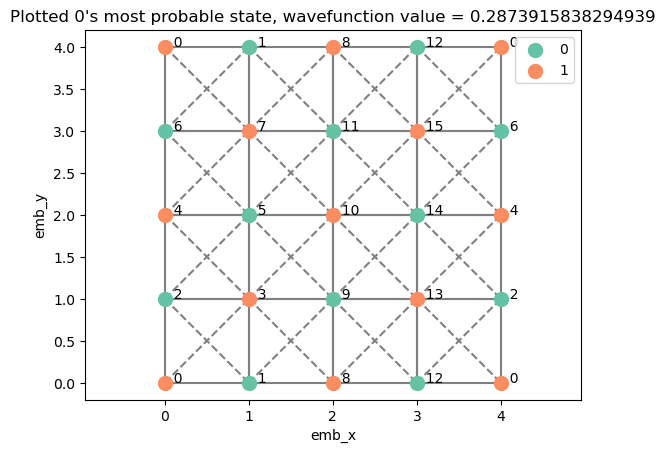

In [ ]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=True
)
system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0)

In [ ]:
# with and without symmetries should give the same ground state energy
assert np.isclose(system_sym.ground_energy, system_nosym.ground_energy)

#### Reference 4×4

In [ ]:
### FROM: https://github.com/twesterhout/nqs-playground/blob/0ba67c9d4ff9f70bbaeea2a9490271dd49ea5091/benchmark/benchmark_apply.py#L9-L20
def load_basis_and_hamiltonian(filename: str, no_symmetries=False, no_inversions=False):
    import yaml

    # logger.info("Loading basis from '{}'...", filename)
    with open(filename, "r") as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
    if no_symmetries:
        config["basis"]["symmetries"] = []
    if no_inversions:
        del config["basis"]["spin_inversion"]
    basis = ls.SpinBasis.load_from_yaml(config["basis"])
    # logger.info("Loading Hamiltonian from '{}'...", filename)
    hamiltonian = ls.Operator.load_from_yaml(config["hamiltonian"], basis)
    return basis, hamiltonian


### END FROM

```
# Initial layout:
    # - permutation: [ 0,  1,  2,  3,
    #                  4,  5,  6,  7,
    #                  8,  9, 10, 11,
    #                 12, 13, 14, 15]
    #
```

In [ ]:
# basis, hamiltonian = load_basis_and_hamiltonian(
#     "heisenberg_square_4x4.yaml", no_symmetries=True, no_inversions=True
# )
# eigenvalues, eigenstates = ls.diagonalize(hamiltonian, k=1)
# assert np.isclose(eigenvalues[0], system_nosym.ground_energy)
# # energy coincides with the reference implementation

#### 6×2 lattice 

number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 462


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -41.2913023078


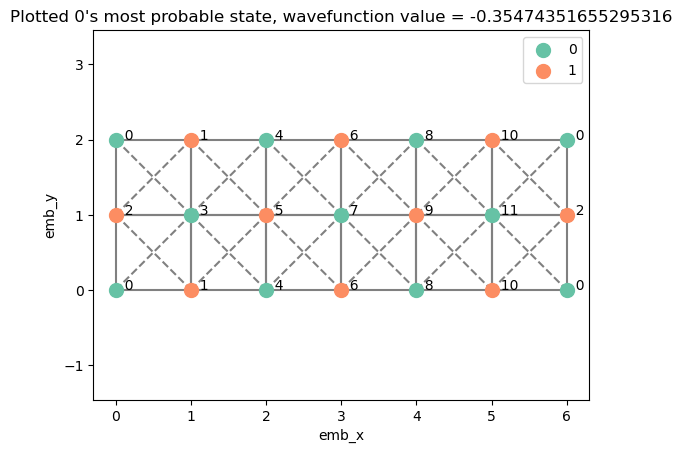

In [ ]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=False
)
system_nosym.get_eigenstates()
system_nosym.visualize_probable_configurations(m=0)

The checkerboard, works as expected.

number_spins=12
Symmetry group contains 24 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 44
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -41.2913023078


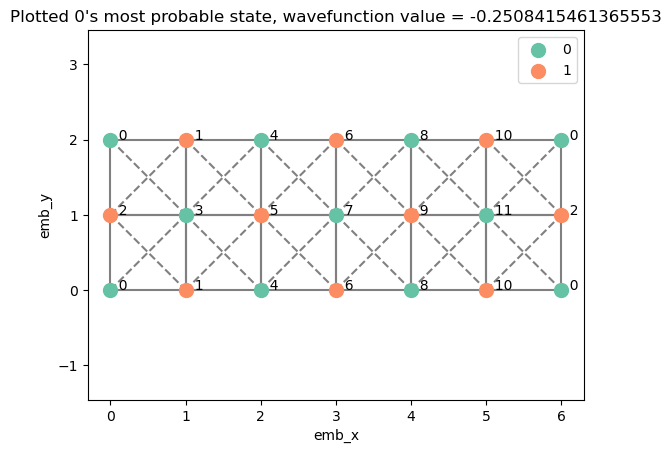

In [ ]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=True
)
system_sym.get_eigenstates()
system_sym.visualize_probable_configurations(m=0)

### Kagome Lattice

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

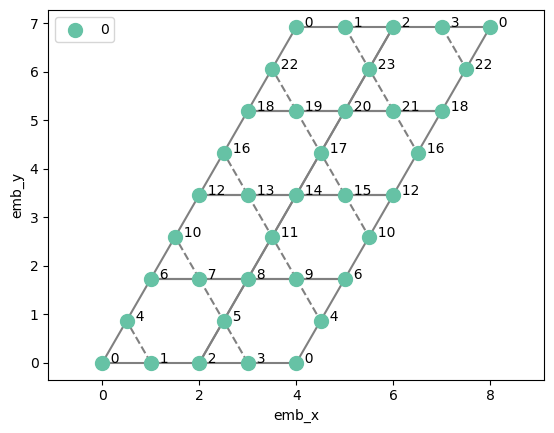

In [ ]:
KagomeLattice(width=2, height=4, enumerate_order="x").plot()

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

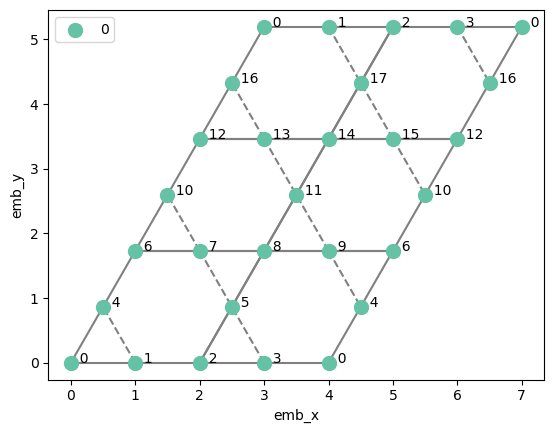

In [ ]:
KagomeLattice(width=2, height=3, enumerate_order="x").plot()

number_spins=24
Symmetry group contains 16 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -46.1341392314


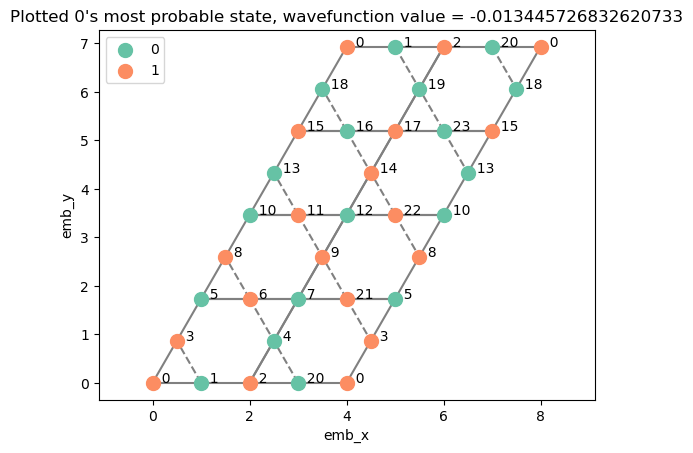

In [ ]:
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4), J1=1, J2=0, use_symmetries=True
)
system.get_eigenstates()
system.visualize_probable_configurations(m=0)

In [ ]:
system.get_df_eigenstate(k=0, canonical_basis=True).sort_values("amplitude")

,eigenstate_coeff,amplitude
10420383,-2.616849e-08,2.616849e-08
13629444,-2.616849e-08,2.616849e-08
3965055,-2.616849e-08,2.616849e-08
12812160,-2.616849e-08,2.616849e-08
6295545,-2.616849e-08,2.616849e-08
...,...,...
12937893,-1.344573e-02,1.344573e-02
10310826,-1.344573e-02,1.344573e-02
3839322,-1.344573e-02,1.344573e-02
6474573,-1.344573e-02,1.344573e-02


number_spins=24
Symmetry group contains 16 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314


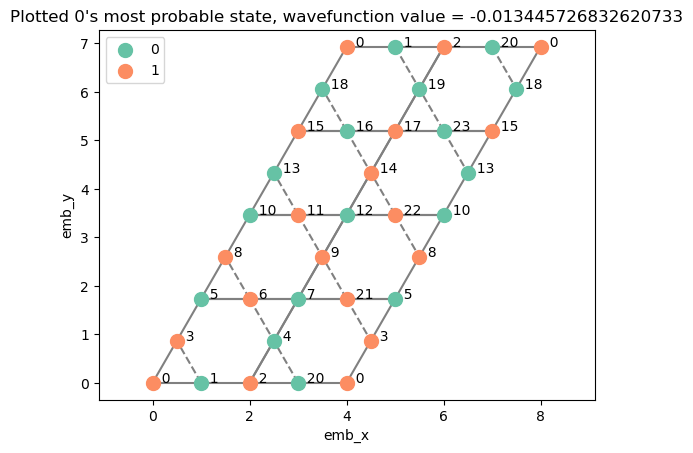

In [ ]:
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4), J1=1, J2=0, use_symmetries=True
)
system.get_eigenstates()
system.visualize_probable_configurations(m=0)

number_spins=18
Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2102
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -34.6339591099


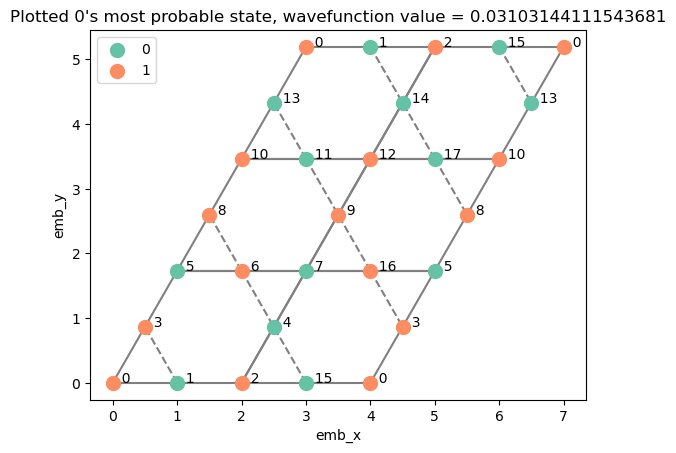

In [ ]:
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=3), J1=1, J2=0, use_symmetries=True
)
system.get_eigenstates()
system.visualize_probable_configurations(m=0)

## Canonical basis

In [ ]:
system = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=True,
    spin_inversion=1,
)
system.get_eigenstates()

system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_eigenstates()

number_spins=16
Symmetry group contains 128 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 107


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-True-1-1.pickle
Ground state energy is -44.9139328337
number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x4-1.0-0.0-False-None-1.pickle
Ground state energy is -44.9139328337


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


(array([-44.91393283]),
 array([[ 0.00075158],
        [ 0.00134471],
        [-0.00087267],
        ...,
        [-0.00087267],
        [ 0.00134471],
        [ 0.00075158]]))

Now we compare the results of the diagonalization in the full basis with the restored ground state obtained from the basis where symmetries are taken into account. Note that the ground state is an eigenvector, so it is defined up to multiplication by a constant. We normalize it and make sure it's real, but the constant still can be either 1 or -1. So to check whether two ground states coincide, we first make first element to have the same sign by multiplying one of the vectors on -1 when necessary.

In [ ]:
system_nosym.get_df_ground_state()

,eigenstate_coeff,amplitude
255,0.000752,0.000752
383,0.001345,0.001345
447,-0.000873,0.000873
479,-0.000873,0.000873
495,0.000694,0.000694
...,...,...
65040,0.000694,0.000694
65056,-0.000873,0.000873
65088,-0.000873,0.000873
65152,0.001345,0.001345


In [ ]:
system.get_df_ground_state(canonical_basis=True)

,eigenstate_coeff,amplitude
255,0.000752,0.000752
383,0.001345,0.001345
447,-0.000873,0.000873
479,-0.000873,0.000873
495,0.000694,0.000694
...,...,...
65040,0.000694,0.000694
65056,-0.000873,0.000873
65088,-0.000873,0.000873
65152,0.001345,0.001345


In [ ]:
system_nosym.get_df_ground_state()

,eigenstate_coeff,amplitude
255,0.000752,0.000752
383,0.001345,0.001345
447,-0.000873,0.000873
479,-0.000873,0.000873
495,0.000694,0.000694
...,...,...
65040,0.000694,0.000694
65056,-0.000873,0.000873
65088,-0.000873,0.000873
65152,0.001345,0.001345


In [ ]:
(
    system_nosym.get_df_ground_state()
    .join(
        system.get_df_ground_state(canonical_basis=True),
        how="outer",
        lsuffix="_x",
        rsuffix="_y",
    )
    .assign(
        ok=lambda x: np.isclose(
            x["eigenstate_coeff_x"],
            x["eigenstate_coeff_y"]
            * np.sign(x["eigenstate_coeff_y"].iloc[0])
            * np.sign(x["eigenstate_coeff_x"].iloc[0]),
        )
    )
)

,eigenstate_coeff_x,amplitude_x,eigenstate_coeff_y,amplitude_y,ok
255,0.000752,0.000752,0.000752,0.000752,True
383,0.001345,0.001345,0.001345,0.001345,True
447,-0.000873,0.000873,-0.000873,0.000873,True
479,-0.000873,0.000873,-0.000873,0.000873,True
495,0.000694,0.000694,0.000694,0.000694,True
...,...,...,...,...,...
65040,0.000694,0.000694,0.000694,0.000694,True
65056,-0.000873,0.000873,-0.000873,0.000873,True
65088,-0.000873,0.000873,-0.000873,0.000873,True
65152,0.001345,0.001345,0.001345,0.001345,True


In [ ]:
assert (
    system_nosym.get_df_ground_state()
    .join(
        system.get_df_ground_state(canonical_basis=True),
        how="outer",
        lsuffix="_x",
        rsuffix="_y",
    )
    .assign(
        ok=lambda x: np.isclose(
            x["eigenstate_coeff_x"],
            x["eigenstate_coeff_y"]
            * np.sign(x["eigenstate_coeff_y"].iloc[0])
            * np.sign(x["eigenstate_coeff_x"].iloc[0]),
        )
    )["ok"]
    .all()
)

Order of elements in the dataframe correponds to order of elements in basis.states

In [ ]:
assert (
    system.get_df_ground_state(canonical_basis=True).index
    == system.canonical_basis.states
).all()

In [ ]:
assert (
    system.get_df_ground_state(canonical_basis=False).index == system.basis.states
).all()

In [ ]:
system_sym.hamiltonian.expression.replace_indices()

'{"expression":"1.0 × σᶻ₀ σᶻ₁ + 1.0 × σᶻ₀ σᶻ₁₁ + 2.0 × σ⁺₀ σ⁻₁ + 2.0 × σ⁺₀ σ⁻₁₁ + 2.0 × σ⁻₀ σ⁺₁ + 2.0 × σ⁻₀ σ⁺₁₁ + 1.0 × σᶻ₁ σᶻ₂ + 2.0 × σ⁺₁ σ⁻₂ + 2.0 × σ⁻₁ σ⁺₂ + 1.0 × σᶻ₂ σᶻ₃ + 2.0 × σ⁺₂ σ⁻₃ + 2.0 × σ⁻₂ σ⁺₃ + 1.0 × σᶻ₃ σᶻ₄ + 2.0 × σ⁺₃ σ⁻₄ + 2.0 × σ⁻₃ σ⁺₄ + 1.0 × σᶻ₄ σᶻ₅ + 2.0 × σ⁺₄ σ⁻₅ + 2.0 × σ⁻₄ σ⁺₅ + 1.0 × σᶻ₅ σᶻ₆ + 2.0 × σ⁺₅ σ⁻₆ + 2.0 × σ⁻₅ σ⁺₆ + 1.0 × σᶻ₆ σᶻ₇ + 2.0 × σ⁺₆ σ⁻₇ + 2.0 × σ⁻₆ σ⁺₇ + 1.0 × σᶻ₇ σᶻ₈ + 2.0 × σ⁺₇ σ⁻₈ + 2.0 × σ⁻₇ σ⁺₈ + 1.0 × σᶻ₈ σᶻ₉ + 2.0 × σ⁺₈ σ⁻₉ + 2.0 × σ⁻₈ σ⁺₉ + 1.0 × σᶻ₉ σᶻ₁₀ + 2.0 × σ⁺₉ σ⁻₁₀ + 2.0 × σ⁻₉ σ⁺₁₀ + 1.0 × σᶻ₁₀ σᶻ₁₁ + 2.0 × σ⁺₁₀ σ⁻₁₁ + 2.0 × σ⁻₁₀ σ⁺₁₁","particle":"spin-1/2"}'

In [ ]:
system.symmerties.generators[3].permutation

array([ 0,  2, 12, 13,  8,  9,  1,  3,  4, 14, 10,  5,  6, 15, 11,  7],
      dtype=int32)

In [ ]:
system.get_df_ground_state(
    unpack_configurations=True, canonical_basis=True
).sort_values("amplitude", ascending=False).iloc[0]["configuration"]

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1], dtype=uint64)

In [ ]:
system.lat.kind_to_edges[1]

[(0, 1),
 (0, 2),
 (2, 3),
 (1, 3),
 (2, 4),
 (4, 5),
 (3, 5),
 (4, 6),
 (6, 7),
 (5, 7),
 (6, 0),
 (7, 1),
 (1, 8),
 (3, 9),
 (8, 9),
 (5, 10),
 (9, 10),
 (7, 11),
 (10, 11),
 (11, 8),
 (8, 12),
 (9, 13),
 (12, 13),
 (10, 14),
 (13, 14),
 (11, 15),
 (14, 15),
 (15, 12),
 (12, 0),
 (13, 2),
 (14, 4),
 (15, 6)]

2023-03-20 17:06:16.738 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=16
2023-03-20 17:06:16.740 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-03-20 17:06:16.757 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 12870
2023-03-20 17:06:16.763 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:94 - Calculating eigenvalues / eigenstates
2023-03-20 17:06:18.473 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -28.5691854425


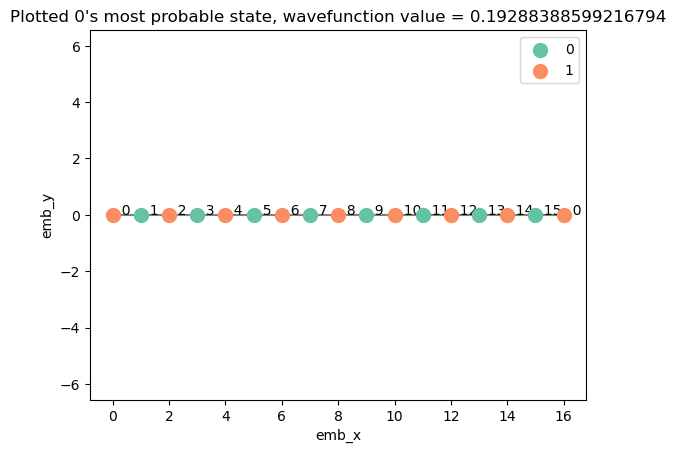

In [ ]:
system = HeisenbergJ1J2(
    ChainLattice(width=16),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
energy, state = system.get_eigenstates()
system.visualize_probable_configurations(m=0)

In [ ]:
energy

array([-14.60437364])

In [ ]:
energy[0] / 4

-3.6510934089371743

In [ ]:
ed_wavefunction = system.get_df_eigenstate(k=0, canonical_basis=True)[
    ["eigenstate_coeff"]
]

In [ ]:
# eleCfg, eleIdx, eleNum

In [ ]:
from ast import literal_eval

In [ ]:
from collections import Counter

In [ ]:
def ele_cfg_to_spin_config(ele_cfg):
    n_spins = len(ele_cfg) // 2
    spin_cfg = np.zeros(n_spins)
    for i in range(n_spins):
        if ele_cfg[i] == -1 and ele_cfg[i + n_spins] == -1:
            raise ValueError(f"Invalid electron configuration: {ele_cfg}")
        elif ele_cfg[i] == -1:
            spin_cfg[i] = 1
        elif ele_cfg[i + n_spins] == -1:
            spin_cfg[i] = 0
    return "".join(map(str, map(int, spin_cfg)))

In [ ]:
ids = set()
for line in Path("wavefunction.dat").read_text().splitlines():
    *keys, value = line.split()
    keys[0]

In [ ]:
df = pd.read_csv(
    "wavefunction.dat",
    sep="\t",
    header=None,
    names=[
        "ele_cfg",
        "ele_idx",
        "ele_num",
        "ele_proj_cnt",
        "qp_start",
        "qp_end",
        "spin_id",
        "wavefunction_coeff",
    ],
).reset_index(drop=True)

In [ ]:
df_walk = df = pd.read_csv(
    "wavefunction_walk.dat",
    sep="\t",
    header=None,
    names=[
        "ele_cfg",
        "ele_idx",
        "ele_num",
        "ele_proj_cnt",
        "qp_start",
        "qp_end",
        "spin_id",
        "wavefunction_coeff",
    ],
).reset_index(drop=True)

In [ ]:
df.dtypes

ele_cfg                object
ele_idx                object
ele_num                object
ele_proj_cnt           object
qp_start                int64
qp_end                  int64
spin_id                 int64
wavefunction_coeff    float64
dtype: object

In [ ]:
system.canonical_basis.states.shape

(12870,)

In [ ]:
df_walk

,ele_cfg,ele_idx,ele_num,ele_proj_cnt,qp_start,qp_end,spin_id,wavefunction_coeff
0,"[0,1,2,3,4,5,6,7,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1...","[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]","[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0...","[0,0]",0,8,65280,0.001696
1,"[0,1,2,3,4,5,6,-1,7,-1,-1,-1,-1,-1,-1,-1,-1,-1...","[0,1,2,3,4,5,6,8,7,9,10,11,12,13,14,15]","[1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0...","[0,0]",0,8,65152,-0.006001
2,"[0,1,2,3,4,5,6,-1,-1,7,-1,-1,-1,-1,-1,-1,-1,-1...","[0,1,2,3,4,5,6,9,7,8,10,11,12,13,14,15]","[1,1,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0...","[0,0]",0,8,64896,-0.003675
3,"[0,1,2,3,4,5,6,-1,-1,-1,7,-1,-1,-1,-1,-1,-1,-1...","[0,1,2,3,4,5,6,10,7,8,9,11,12,13,14,15]","[1,1,1,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0...","[0,0]",0,8,64384,0.014579
4,"[0,1,2,3,4,5,6,-1,-1,-1,-1,7,-1,-1,-1,-1,-1,-1...","[0,1,2,3,4,5,6,11,7,8,9,10,12,13,14,15]","[1,1,1,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0...","[0,0]",0,8,63360,-0.021259
...,...,...,...,...,...,...,...,...
12865,"[-1,-1,-1,-1,-1,-1,-1,3,6,5,0,2,-1,7,4,1,0,1,2...","[10,15,11,7,14,9,8,13,0,1,2,3,4,5,6,12]","[0,0,0,0,0,0,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1...","[0,0]",0,8,4223,0.020858
12866,"[-1,-1,-1,-1,-1,-1,-1,3,6,5,0,2,7,-1,4,1,0,1,2...","[10,15,11,7,14,9,8,12,0,1,2,3,4,5,6,13]","[0,0,0,0,0,0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1...","[0,0]",0,8,8319,-0.003330
12867,"[-1,-1,-1,-1,-1,-1,-1,3,6,5,0,2,7,4,-1,1,0,1,2...","[10,15,11,7,13,9,8,12,0,1,2,3,4,5,6,14]","[0,0,0,0,0,0,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1...","[0,0]",0,8,16511,0.001114
12868,"[-1,-1,-1,-1,-1,-1,-1,3,6,5,0,2,7,4,1,-1,0,1,2...","[10,14,11,7,13,9,8,12,0,1,2,3,4,5,6,15]","[0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1...","[0,0]",0,8,32895,-0.004001


In [ ]:
df.groupby("spin_id")[["wavefunction_coeff"]].last().join(
    df_walk.set_index("spin_id")["wavefunction_coeff"], rsuffix="_walk"
).assign(diff=lambda x: x["wavefunction_coeff_walk"] - x["wavefunction_coeff"])[
    "diff"
].max() == 0

True

In [ ]:
### FROM: https://stackoverflow.com/a/1504565/3025981
def perm_parity(permutation):
    permutation = list(permutation)
    length = len(permutation)
    elements_seen = [False] * length
    cycles = 0
    for index, already_seen in enumerate(elements_seen):
        if already_seen:
            continue
        cycles += 1
        current = index
        while not elements_seen[current]:
            elements_seen[current] = True
            current = permutation[current]
    return (length - cycles) % 2 == 0


### END FROM

In [ ]:
# generated_wavefunction = (
#     df.assign(
#         amplitude=lambda df: np.abs(df["value"]),
#         sign_correction=lambda df: [1 - 2 * perm_parity(literal_eval(x)) for x in df["ele_idx"]],
#     )
#     .assign(generated_wavefunction_coeff=lambda df: df["value"] * df["sign_correction"])[
#         ["spin_config", "generated_wavefunction_coeff"]
#     ]
#     .assign(spin_config=lambda df: [int(x, base=2) for x in df["spin_config"]])
# ).set_index('spin_config')['generated_wavefunction_coeff']

In [ ]:
assert (
    df.groupby("spin_id")["wavefunction_coeff"]
    .agg(["mean", "std"])
    .dropna()
    .assign(relerror=lambda df: df["std"] / np.abs(df["mean"]))["relerror"]
    .max()
    < 1e-6
)

In [ ]:
generated_wavefunction = df.groupby("spin_id").last()

In [ ]:
generated_wavefunction

,wavefunction_coeff
spin_id,
15,1.842147
23,-8.569912
27,13.454132
29,-8.569971
30,1.842093
...,...
225,1.842093
226,-8.569971
228,13.454132


In [ ]:
ed_wavefunction

,eigenstate_coeff
15,0.007470
23,-0.034742
27,0.054545
29,-0.034742
30,0.007470
...,...
225,0.007470
226,-0.034742
228,0.054545
232,-0.034742


In [ ]:
ed_wavefunction.join(generated_wavefunction, how="right")

,eigenstate_coeff,wavefunction_coeff
spin_id,,
15,0.007470,1.842147
23,-0.034742,-8.569912
27,0.054545,13.454132
29,-0.034742,-8.569971
30,0.007470,1.842093
...,...,...
225,0.007470,1.842093
226,-0.034742,-8.569971
228,0.054545,13.454132


In [ ]:
ed_wavefunction.join(generated_wavefunction, how="right").assign(
    generated_rescaled=lambda df: df["generated_wavefunction_coeff"]
    * df["eigenstate_coeff"].iloc[0]
    / df["generated_wavefunction_coeff"].iloc[0]
).assign(diff=lambda df: df["eigenstate_coeff"] - df["generated_rescaled"]).assign(
    rel_error=lambda df: np.abs(df["diff"]) / np.abs(df["eigenstate_coeff"])
).assign(
    abs_error=lambda df: np.abs(df["diff"])
).sort_values(
    "abs_error", ascending=False
)[
    "abs_error"
]

spin_config_idx
85     7.911182e-05
170    7.911182e-05
43     3.520005e-05
212    3.520005e-05
178    3.520005e-05
           ...     
135    2.189628e-07
30     1.257009e-07
225    1.257009e-07
240    1.335737e-16
15     0.000000e+00
Name: abs_error, Length: 70, dtype: float64

<AxesSubplot: >

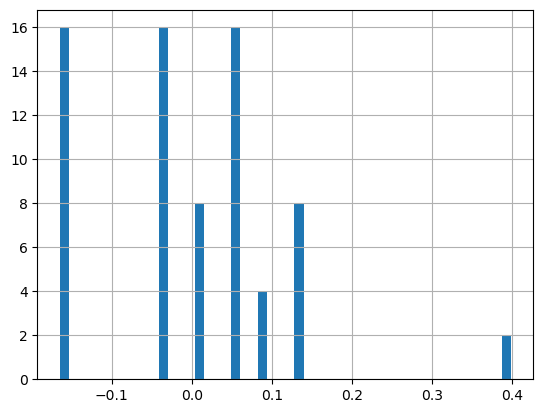

In [ ]:
ed_wavefunction.join(generated_wavefunction, how="right").assign(
    generated_rescaled=lambda df: df["wavefunction_coeff"]
    * df["eigenstate_coeff"].iloc[0]
    / df["wavefunction_coeff"].iloc[0]
).dropna()["eigenstate_coeff"].hist(bins=50)

<AxesSubplot: >

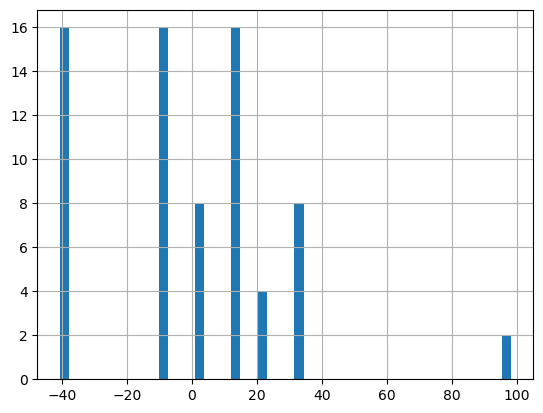

In [ ]:
ed_wavefunction.join(generated_wavefunction, how="right").assign(
    generated_rescaled=lambda df: df["generated_wavefunction_coeff"]
    * df["eigenstate_coeff"].iloc[0]
    / df["generated_wavefunction_coeff"].iloc[0]
).dropna()["generated_wavefunction_coeff"].hist(bins=50)

In [ ]:
ed_wavefunction.join(generated_wavefunction, how="right").assign(
    generated_rescaled=lambda df: df["wavefunction_coeff"]
    * df["eigenstate_coeff"].iloc[0]
    / df["wavefunction_coeff"].iloc[0]
).assign(diff=lambda df: df["eigenstate_coeff"] - df["generated_rescaled"]).assign(
    rel_error=lambda df: np.abs(df["diff"]) / np.abs(df["eigenstate_coeff"])
).assign(
    abs_error=lambda df: np.abs(df["diff"])
)[
    ["rel_error", "abs_error"]
].max()

rel_error    0.000231
abs_error    0.000079
dtype: float64

In [ ]:
eigenstate_coeff = ed_wavefunction.join(generated_wavefunction, how="right")[
    "eigenstate_coeff"
]
generated_wavefunction_coeff = ed_wavefunction.join(
    generated_wavefunction, how="right"
)["wavefunction_coeff"]
(eigenstate_coeff @ generated_wavefunction_coeff) / (
    np.linalg.norm(eigenstate_coeff) * np.linalg.norm(generated_wavefunction_coeff)
)

0.999999999942256

In [ ]:
ed_wavefunction.join(generated_wavefunction, how="right").assign(
    generated_rescaled=lambda df: df["generated_wavefunction_coeff"]
    * df["eigenstate_coeff"].iloc[0]
    / df["generated_wavefunction_coeff"].iloc[0]
).assign(
    product=lambda df: df["eigenstate_coeff"] * df["generated_rescaled"],
    weight=lambda df: np.abs(df["eigenstate_coeff"]) ** 2,
    rescaled_prob=lambda df: df["generated_rescaled"] ** 2,
).sum().to_frame().T.assign(
    overlap=lambda df: df["product"] / df["weight"] / np.sqrt(df["rescaled_prob"])
)

,eigenstate_coeff,generated_wavefunction_coeff,generated_rescaled,product,weight,rescaled_prob,overlap
0,8.673617e-16,-0.021132,-0.000086,1.000203,1.0,1.000405,1.0


In [ ]:
lattice = KagomeLattice(2, 4)
system = HeisenbergJ1J2(
    lattice=lattice, J1=1, J2=1, use_symmetries=False, spin_inversion=None
)
system.get_eigenstates(10)

2023-08-12 19:05:54.008 | DEBUG    | heisenberg_hamiltonians:__init__:459 - number_spins=24
2023-08-12 19:05:54.012 | DEBUG    | heisenberg_hamiltonians:__init__:469 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-12 19:05:54.285 | DEBUG    | heisenberg_hamiltonians:__init__:478 - Hilbert space dimension is 2704156
2023-08-12 19:05:54.306 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:101 - Calculating eigenvalues / eigenstates
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 640; batchedOperatorChunkSize: 4226
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 640; batchedOperatorChunkSize: 4226
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 640; batchedOperatorChunkSize: 4226
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 640; batchedOperatorChunkSize: 4226
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 640; batchedOperatorChunkSize: 4226
[Debug]   [LOCALE0]   remoteBu

(array([-43.03958899, -42.82459918, -42.7457909 , -42.64435572,
        -42.638814  , -42.638814  , -42.56683915, -42.56683915,
        -42.56683915, -42.34783072]),
 array([[ 4.90411613e-09,  6.52025278e-08,  3.40441081e-08, ...,
          1.74725386e-08,  3.59105595e-09,  1.75996851e-08],
        [ 2.80245214e-08,  1.91775319e-08,  1.66782354e-10, ...,
          3.44926826e-08,  2.74208079e-08, -8.55468716e-08],
        [-2.06506511e-18,  2.73146829e-18, -1.17569822e-08, ...,
          1.30967006e-08, -3.96488767e-09,  4.71226313e-18],
        ...,
        [-1.25774652e-17,  8.70145992e-18, -1.17569822e-08, ...,
          1.30967006e-08, -3.96488767e-09,  1.34821837e-18],
        [ 2.80245213e-08,  1.91775319e-08,  1.66782354e-10, ...,
          3.44926826e-08,  2.74208079e-08, -8.55468716e-08],
        [ 4.90411610e-09,  6.52025278e-08,  3.40441081e-08, ...,
          1.74725386e-08,  3.59105595e-09,  1.75996851e-08]]))

In [ ]:
_, eigenstates = system.get_eigenstates(10)

In [ ]:
signs = np.sign(eigenstates)

(array([ 1.,  2.,  1.,  2.,  6., 17., 10.,  3.,  2.,  1.]),
 array([-0.07453268, -0.06205219, -0.0495717 , -0.0370912 , -0.02461071,
        -0.01213022,  0.00035028,  0.01283077,  0.02531126,  0.03779175,
         0.05027225]),
 <BarContainer object of 10 artists>)

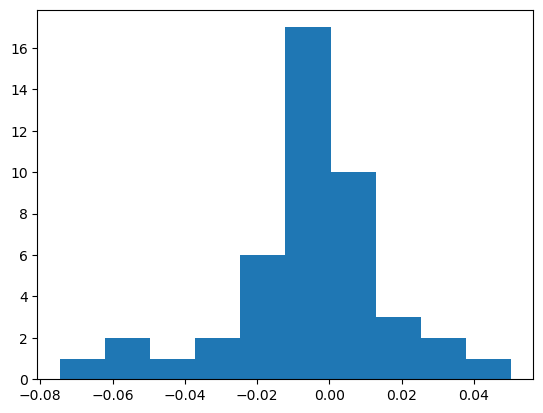

In [ ]:
plt.hist(((signs.T @ signs) / signs.shape[0])[np.triu_indices(signs.shape[1], 1)])